This is header:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import *

df = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")



In [7]:
from sklearn.model_selection import train_test_split

# Convert date column to datetime, then to numerical (days since first date)
df['Date'] = pd.to_datetime(df['Date'])  # Capital 'D'
df['date_numeric'] = (df['Date'] - df['Date'].min()).dt.days

# Features and target
x = df['date_numeric'].values.reshape(-1, 1)
y = np.array(df[["Close"]])

# Split the data
x_t, X_test, y_t, y_test = train_test_split(x, y, test_size=0.2)

# Train and predict
model = LinearRegression()
model.fit(x_t, y_t)
ypred = model.predict(X_test)

In [ ]:
# Predict prices for the next 30 days
last_day = df['date_numeric'].max()
future_days = np.arange(last_day + 1, last_day + 31).reshape(-1, 1)
future_prices = model.predict(future_days)

[[34.27212118]
 [34.27836669]
 [34.28461219]
 [34.29085769]
 [34.2971032 ]
 [34.3033487 ]
 [34.3095942 ]
 [34.31583971]
 [34.32208521]
 [34.32833071]
 [34.33457622]
 [34.34082172]
 [34.34706722]
 [34.35331273]
 [34.35955823]
 [34.36580373]
 [34.37204924]
 [34.37829474]
 [34.38454024]
 [34.39078575]
 [34.39703125]
 [34.40327675]
 [34.40952226]
 [34.41576776]
 [34.42201326]
 [34.42825877]
 [34.43450427]
 [34.44074978]
 [34.44699528]
 [34.45324078]]


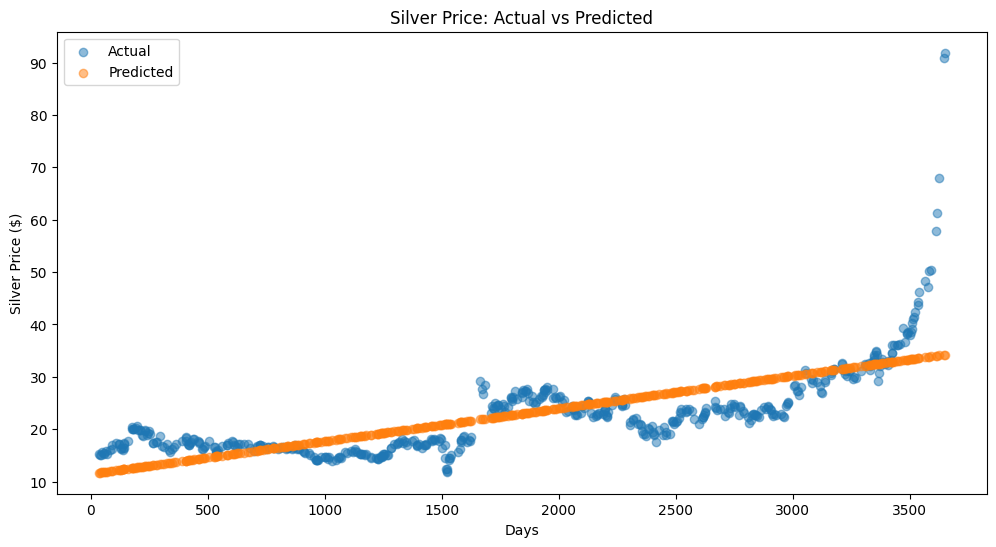

In [13]:
plt.figure(figsize=(12, 6))
plt.scatter(X_test, y_test, alpha=0.5, label='Actual')
plt.scatter(X_test, ypred, alpha=0.5, label='Predicted')
plt.xlabel('Days')
plt.ylabel('Silver Price ($)')
plt.legend()
plt.title('Silver Price: Actual vs Predicted')
plt.show()

Polynomial Regression


In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data (using the same x and y from before)
x = df['date_numeric'].values.reshape(-1, 1)
y = df['Close'].values

# Split the data
x_t, X_test, y_t, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create polynomial regression model (degree 2, 3, or 4 - experiment!)
degree = 3
poly_model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)

# Train and predict
poly_model.fit(x_t, y_t)
ypred_poly = poly_model.predict(X_test)

# Evaluate
print(f"Polynomial Degree: {degree}")
print(f"R² Score: {r2_score(y_test, ypred_poly):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ypred_poly)):.4f}")

Polynomial Degree: 3
R² Score: 0.7114
RMSE: 4.6742


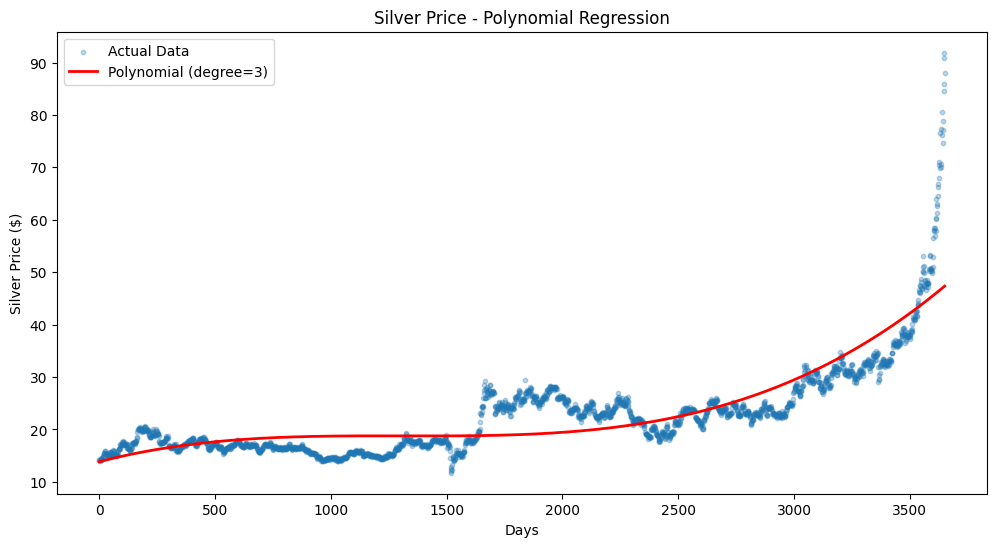

In [15]:
# Sort for smooth curve plotting
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_pred_curve = poly_model.predict(x_range)

plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.3, label='Actual Data', s=10)
plt.plot(x_range, y_pred_curve, color='red', linewidth=2, label=f'Polynomial (degree={degree})')
plt.xlabel('Days')
plt.ylabel('Silver Price ($)')
plt.title('Silver Price - Polynomial Regression')
plt.legend()
plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
x = df['date_numeric'].values.reshape(-1, 1)
y = df['Close'].values

# Split the data
x_t, X_test, y_t, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Max depth of each tree
    random_state=42
)

# Train and predict
rf_model.fit(x_t, y_t)
ypred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Regression")
print(f"R² Score: {r2_score(y_test, ypred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ypred_rf)):.4f}")

Random Forest Regression
R² Score: 0.9955
RMSE: 0.5836


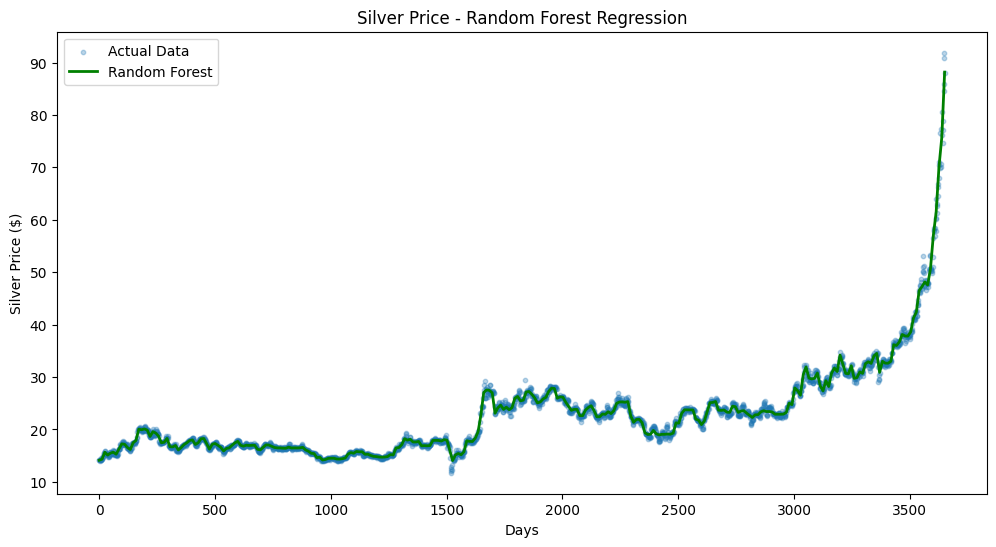

In [17]:
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_pred_curve = rf_model.predict(x_range)

plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.3, label='Actual Data', s=10)
plt.plot(x_range, y_pred_curve, color='green', linewidth=2, label='Random Forest')
plt.xlabel('Days')
plt.ylabel('Silver Price ($)')
plt.title('Silver Price - Random Forest Regression')
plt.legend()
plt.show()

In [18]:
# Get the last day in your data
last_day = df['date_numeric'].max()
last_date = df['Date'].max()

# Forecast next 30 days
future_days = np.arange(last_day + 1, last_day + 31).reshape(-1, 1)
future_prices = rf_model.predict(future_days)

# Create forecast dataframe
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Predicted_Price': future_prices
})

print(forecast_df)

         Date  Predicted_Price
0  2026-01-17        88.173793
1  2026-01-18        88.173793
2  2026-01-19        88.173793
3  2026-01-20        88.173793
4  2026-01-21        88.173793
5  2026-01-22        88.173793
6  2026-01-23        88.173793
7  2026-01-24        88.173793
8  2026-01-25        88.173793
9  2026-01-26        88.173793
10 2026-01-27        88.173793
11 2026-01-28        88.173793
12 2026-01-29        88.173793
13 2026-01-30        88.173793
14 2026-01-31        88.173793
15 2026-02-01        88.173793
16 2026-02-02        88.173793
17 2026-02-03        88.173793
18 2026-02-04        88.173793
19 2026-02-05        88.173793
20 2026-02-06        88.173793
21 2026-02-07        88.173793
22 2026-02-08        88.173793
23 2026-02-09        88.173793
24 2026-02-10        88.173793
25 2026-02-11        88.173793
26 2026-02-12        88.173793
27 2026-02-13        88.173793
28 2026-02-14        88.173793
29 2026-02-15        88.173793


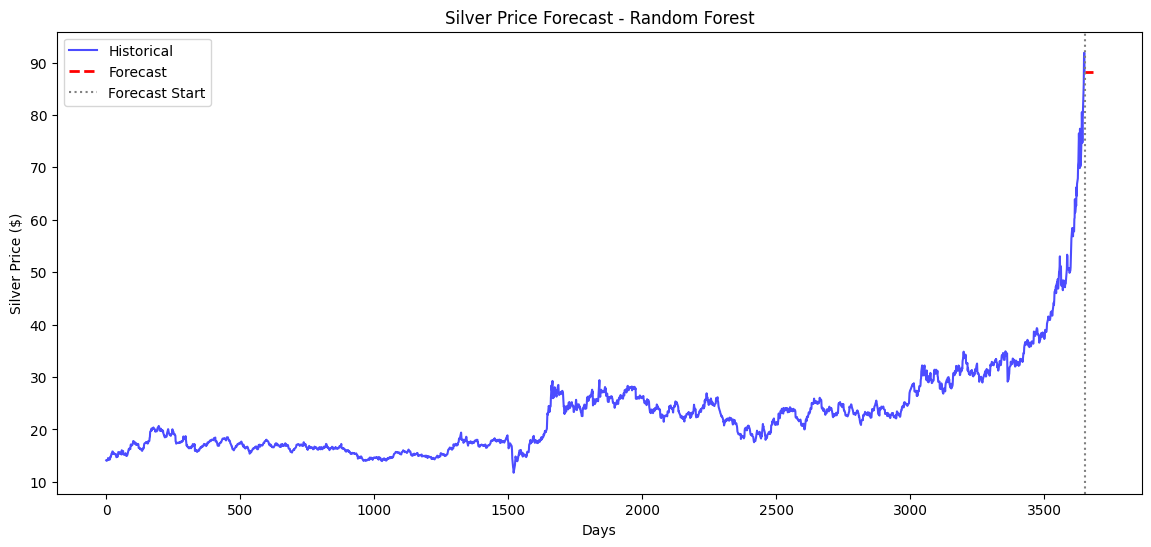

In [22]:
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(df['date_numeric'], df['Close'], alpha=0.7, label='Historical', color='blue')

# Forecast
plt.plot(future_days, future_prices, linewidth=2, label='Forecast', color='red', linestyle='--')

# Mark where forecast begins
plt.axvline(x=last_day, color='gray', linestyle=':', label='Forecast Start')

plt.xlabel('Days')
plt.ylabel('Silver Price ($)')
plt.title('Silver Price Forecast - Random Forest')
plt.legend()
plt.show()

In [24]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
x = df['date_numeric'].values.reshape(-1, 1)
y = df['Close'].values

# Split the data
x_t, X_test, y_t, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale features (important for SVR!)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_t_scaled = scaler_x.fit_transform(x_t)
X_test_scaled = scaler_x.transform(X_test)
y_t_scaled = scaler_y.fit_transform(y_t.reshape(-1, 1)).ravel()

# Create SVR model
svr_model = SVR(
    kernel='rbf',    # 'linear', 'poly', 'rbf', 'sigmoid'
    C=100,           # Regularization
    epsilon=0.1      # Margin of tolerance
)

# Train and predict
svr_model.fit(x_t_scaled, y_t_scaled)
ypred_scaled = svr_model.predict(X_test_scaled)
ypred_svr = scaler_y.inverse_transform(ypred_scaled.reshape(-1, 1)).ravel()

# Evaluate
print("Support Vector Regression (SVR)")
print(f"R² Score: {r2_score(y_test, ypred_svr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ypred_svr)):.4f}")

Support Vector Regression (SVR)
R² Score: 0.9127
RMSE: 2.5710


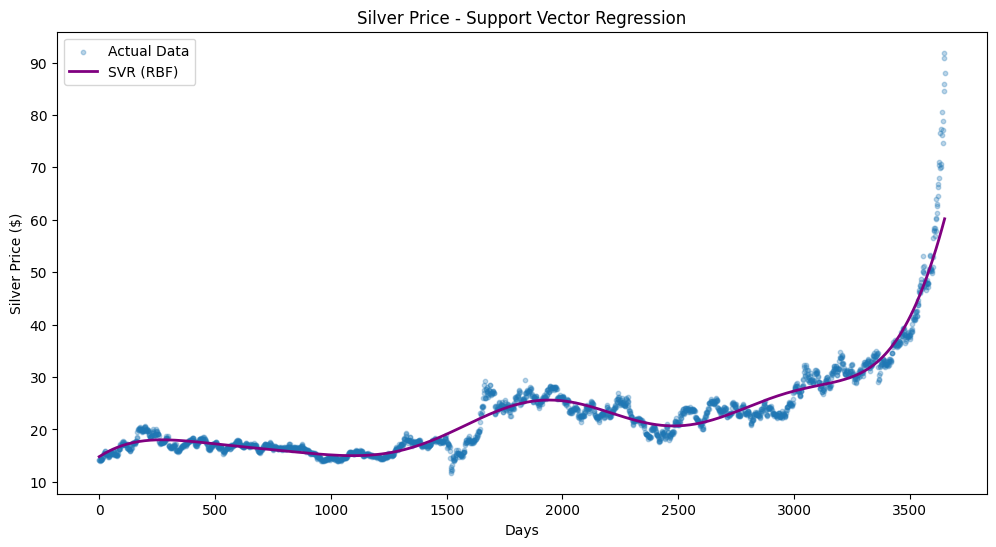

In [25]:
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
x_range_scaled = scaler_x.transform(x_range)
y_pred_scaled = svr_model.predict(x_range_scaled)
y_pred_curve = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.3, label='Actual Data', s=10)
plt.plot(x_range, y_pred_curve, color='purple', linewidth=2, label='SVR (RBF)')
plt.xlabel('Days')
plt.ylabel('Silver Price ($)')
plt.title('Silver Price - Support Vector Regression')
plt.legend()
plt.show()

In [27]:
# Forecast next 30 days
last_day = df['date_numeric'].max()
future_days = np.arange(last_day + 1, last_day + 31).reshape(-1, 1)
future_scaled = scaler_x.transform(future_days)
future_pred_scaled = svr_model.predict(future_scaled)
future_prices = scaler_y.inverse_transform(future_pred_scaled.reshape(-1, 1)).ravel()

print("30-Day Forecast:")
for i, price in enumerate(future_prices, 1):
    print(f"Day {i}: ${price:.2f}")

30-Day Forecast:
Day 1: $60.35
Day 2: $60.52
Day 3: $60.68
Day 4: $60.85
Day 5: $61.02
Day 6: $61.18
Day 7: $61.35
Day 8: $61.52
Day 9: $61.69
Day 10: $61.86
Day 11: $62.03
Day 12: $62.20
Day 13: $62.38
Day 14: $62.55
Day 15: $62.72
Day 16: $62.89
Day 17: $63.07
Day 18: $63.24
Day 19: $63.42
Day 20: $63.59
Day 21: $63.77
Day 22: $63.95
Day 23: $64.12
Day 24: $64.30
Day 25: $64.48
Day 26: $64.66
Day 27: $64.84
Day 28: $65.02
Day 29: $65.20
Day 30: $65.38
